## **Load model, data etc and prepare for evaluation**

In [2]:
import torch
import pandas as pd
from torch.utils.data import DataLoader
from tqdm import tqdm

from CNN import InfernoCalibNet, ChestXRayDataset, CALIB_DIR

def evaluate_inferno_logits():
    torch.cuda.empty_cache()

    df_meta = pd.read_csv(CALIB_DIR / "calibration_test.csv")
    test_dataset = ChestXRayDataset(CALIB_DIR / "calibration_test.csv", transform=False)
    test_loader = DataLoader(
        test_dataset, batch_size=32, shuffle=False, num_workers=8, pin_memory=True
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = InfernoCalibNet(num_classes=2).to(device)
    model.load_state_dict(torch.load(CALIB_DIR / "InfernoCalibNetML.pth", weights_only=True))
    model.eval()

    preds_list = []
    targets_list = []

    with torch.no_grad():
        for inputs, targets in tqdm(test_loader, desc="Evaluating", leave=False):
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            preds_list.append(outputs.cpu())
            targets_list.append(targets.cpu())

    preds_tensor = torch.cat(preds_list)
    targets_tensor = torch.cat(targets_list)

    df_meta = df_meta.reset_index(drop=True)
    df_meta["LOGIT_EFFUSION"] = preds_tensor[:, 0].numpy()
    df_meta["LABEL_EFFUSION"] = targets_tensor[:, 0].numpy().astype(int)
    df_meta["LOGIT_ATELECTASIS"] = preds_tensor[:, 1].numpy()
    df_meta["LABEL_ATELECTASIS"] = targets_tensor[:, 1].numpy().astype(int)

    loss_fn = torch.nn.BCEWithLogitsLoss()
    avg_loss = loss_fn(preds_tensor, targets_tensor).item()

    return df_meta, preds_tensor, targets_tensor, avg_loss

df, preds, targets, loss = evaluate_inferno_logits()

## **Evaluation script with utility matrix for multilabel predictions**

─────────────────────────────────────────────── Evaluation Metrics ────────────────────────────────────────────────

Test BCEWithLogitsLoss: 0.4454

                         Classification Metrics                         
┏━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃    Label    ┃ Precision ┃ Recall ┃ F1-score ┃  AUROC ┃ Avg Precision ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━┩
│  Effusion   │    0.7743 │ 0.6600 │   0.7126 │ 0.8831 │        0.7658 │
├─────────────┼───────────┼────────┼──────────┼────────┼───────────────┤
│ Atelectasis │    0.6261 │ 0.4862 │   0.5473 │ 0.7872 │        0.6059 │
└─────────────┴───────────┴────────┴──────────┴────────┴───────────────┘

Average Utility Score: 0.8945

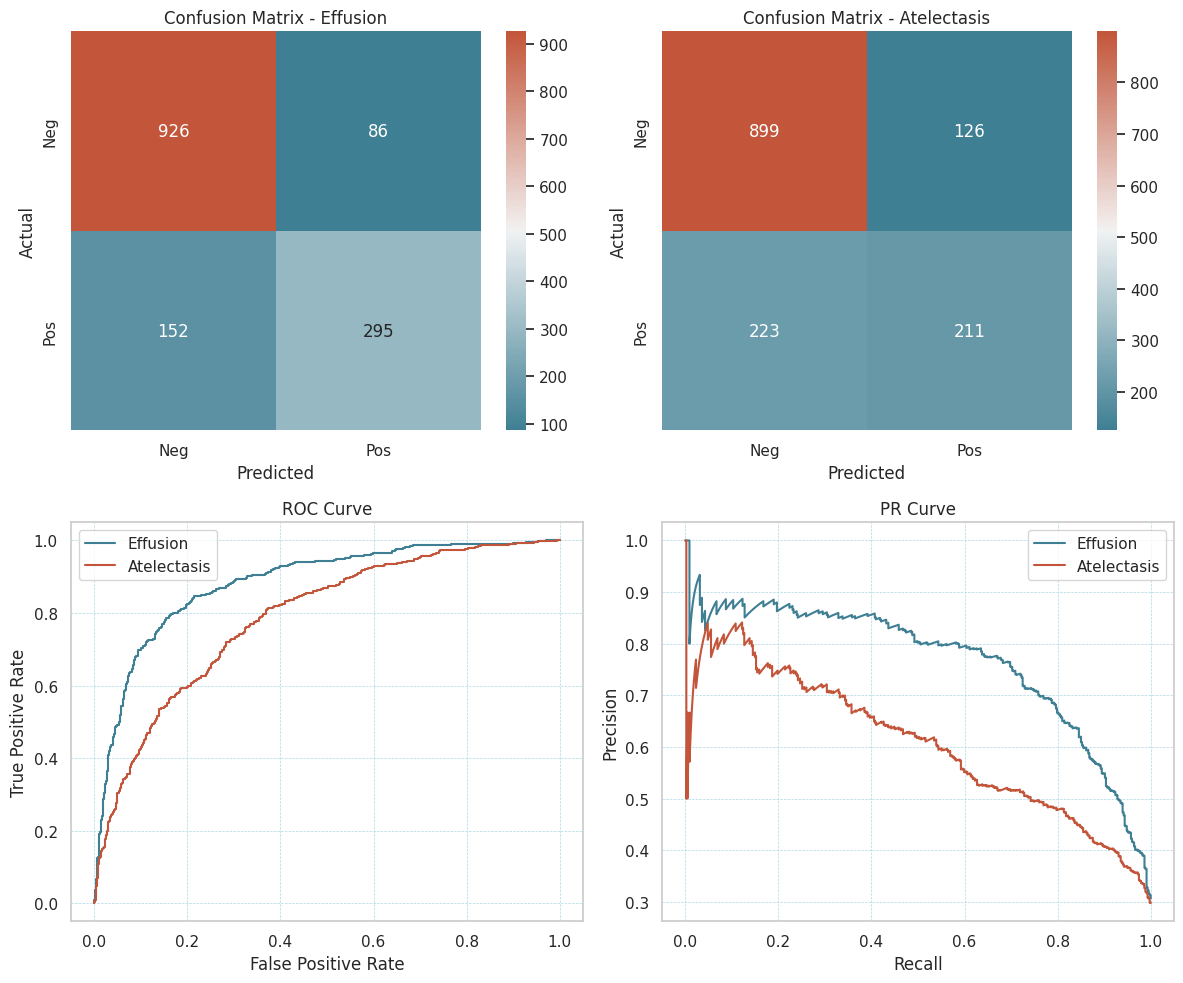

In [ ]:
from rich.console import Console
from rich.table import Table

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)

sns.set_theme(style="whitegrid", palette=sns.diverging_palette(220, 20, n=2))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

console = Console()

# Define the utility matrix corresponding to prediction vs true (Effusion, Atelectasis)
utility_matrix = np.array([
    [1.00, 0.55, 0.60, 0.40],  # Predict: none
    [0.90, 1.00, 0.65, 0.75],  # Predict: effusion only
    [0.90, 0.65, 1.00, 0.75],  # Predict: atelectasis only
    [0.80, 0.85, 0.85, 1.00],  # Predict: both
])

# Map binary outputs to index for utility matrix
label_index = lambda e, a: e + 2 * a


def runMetrics(preds_tensor, targets_tensor, avg_loss):
    probs = torch.sigmoid(preds_tensor).numpy()
    targets = targets_tensor.numpy()

    console.rule("[bold cyan]Evaluation Metrics")
    console.print(f"Test BCEWithLogitsLoss: {avg_loss:.4f}")

    table = Table(title="Classification Metrics", show_lines=True)
    table.add_column("Label", justify="center")
    table.add_column("Precision", justify="right")
    table.add_column("Recall", justify="right")
    table.add_column("F1-score", justify="right")
    table.add_column("AUROC", justify="right")
    table.add_column("Avg Precision", justify="right")

    roc_data = {}
    pr_data = {}
    confusion_matrices = {}

    decisions_util = []
    true_vals_util = []

    for i, label_name in zip([0, 1], ["Effusion", "Atelectasis"]):
        p = probs[:, i] > 0.5
        t = targets[:, i]

        prec = precision_score(t, p)
        rec = recall_score(t, p)
        f1 = f1_score(t, p)
        auroc = roc_auc_score(t, probs[:, i])
        ap = average_precision_score(t, probs[:, i])

        table.add_row(label_name, f"{prec:.4f}", f"{rec:.4f}", f"{f1:.4f}", f"{auroc:.4f}", f"{ap:.4f}")

        fpr, tpr, _ = roc_curve(t, probs[:, i])
        prec_curve, rec_curve, _ = precision_recall_curve(t, probs[:, i])

        roc_data[label_name] = (fpr, tpr)
        pr_data[label_name] = (rec_curve, prec_curve)

        cm = confusion_matrix(t, p)
        confusion_matrices[label_name] = cm

    console.print(table)

    # Compute utility-based evaluation
    for prob_vec, true_vec in zip(probs, targets):
        pred_bin = (prob_vec > 0.5).astype(int)
        pred_idx = int(label_index(pred_bin[0], pred_bin[1]))
        true_idx = int(label_index(int(true_vec[0]), int(true_vec[1])))
        decisions_util.append(pred_idx)
        true_vals_util.append(true_idx)

    avg_utility = np.mean([utility_matrix[p, t] for p, t in zip(decisions_util, true_vals_util)])
    console.print(f"\n[bold green]Average Utility Score: {avg_utility:.4f}")

    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    for idx, (label, cm) in enumerate(confusion_matrices.items()):
        ax = axes[0, idx]
        sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"], ax=ax)
        ax.set_title(f"Confusion Matrix - {label}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    for idx, (label, (fpr, tpr)) in enumerate(roc_data.items()):
        axes[1, 0].plot(fpr, tpr, label=label)
    axes[1, 0].set_title("ROC Curve")
    axes[1, 0].set_xlabel("False Positive Rate")
    axes[1, 0].set_ylabel("True Positive Rate")
    axes[1, 0].legend()
    axes[1, 0].grid(True, linestyle='--', linewidth=0.5, color='lightblue')

    for idx, (rec_curve, prec_curve) in enumerate(pr_data.values()):
        axes[1, 1].plot(rec_curve, prec_curve, label=list(pr_data.keys())[idx])
    axes[1, 1].set_title("PR Curve")
    axes[1, 1].set_xlabel("Recall")
    axes[1, 1].set_ylabel("Precision")
    axes[1, 1].legend()
    axes[1, 1].grid(True, linestyle='--', linewidth=0.5, color='lightblue')

    plt.tight_layout()
    plt.show()

runMetrics(preds, targets, loss)

## **Evaluate (ematrix) inferno improvement**

In [1]:
import subprocess
from pathlib import Path

RSCRIPT_PATH = Path("../RScripts/utility.R")

subprocess.run(["Rscript", str(RSCRIPT_PATH)], check=True)

[1] 0.918026
[1] 0.8945168


CompletedProcess(args=['Rscript', '../RScripts/utility.R'], returncode=0)